In [ ]:
import numpy as np
from scipy.stats import norm, rv_discrete

In [ ]:
low_bound = 670
high_bound = 925
inc=5
sale_price=920
values = np.arange(low_bound, high_bound, inc)
probs = np.ones(len(values)) / len(values)

dist = rv_discrete(name='reserve_dist', values=(values, probs))


In [ ]:
x=[]
y=[]
best=(0,0)
for i in range(670, 925, 5):
  cdf_res=dist.cdf(i+1)
  expected_val = (sale_price-(i+1)) * cdf_res
  x.append(i+1)
  y.append(expected_val)
  if expected_val>best[1]:
    best=(i+1,expected_val)

In [ ]:
# Optimal Bid 1 answer
print(best)

(791, np.float64(63.23529411764703))


In [ ]:
dist.cdf(796)

np.float64(0.5098039215686272)

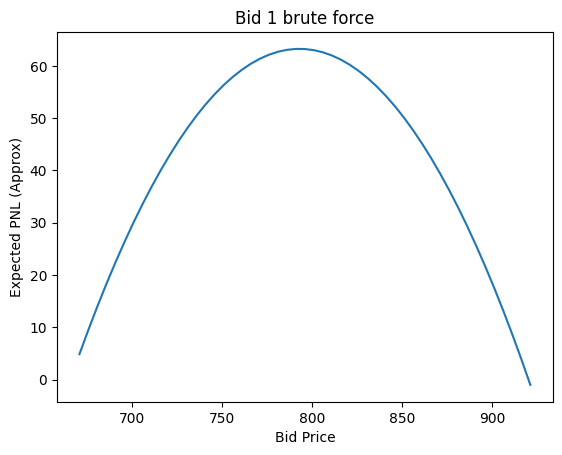

In [ ]:
import matplotlib.pyplot as plt
plt.title("Bid 1 brute force")
plt.xlabel("Bid Price")
plt.ylabel("Expected PNL (Approx)")
plt.plot(x,y)
plt.show()

In [ ]:
import numpy as np

bids = np.arange(670, 925, 5)

values = np.arange(670, 925, 5)

sale_price = 920

b1 = 795

def simulate_population(n_players=5000):
    """
    Simple behavioral mixture model
    """
    b2s = []

    for _ in range(n_players):
        r = np.random.choice(["aggro", "middle", "high", "noise"],
                             p=[0.45, 0.25, 0.2, 0.1])

        if r == "aggro":
            b2 = np.random.normal(866, 2)
        elif r == "middle":
            b2 = np.random.normal(861, 1)
        elif r == "low":
            b2 = np.random.normal(850, 15)
        else:
            b2 = np.random.uniform(796, 920)

        b2s.append(np.clip(b2, 670, 920))

    return np.array(b2s)


def expected_pnl_b2(b2, avg_b2, tail_prob):
    """
    tail_prob = P(r > b1), i.e. reaching second round
    """

    base_profit = 920 - b2

    if b2 > avg_b2:
        return tail_prob * base_profit
    else:
        penalty = ((920 - avg_b2) / (920 - b2)) ** 3
        return tail_prob * base_profit * penalty

def best_response():
    best_b2 = None
    best_val = -1e18

    for _ in range(10):
        b2_pop = simulate_population()

        avg_b2 = np.mean(b2_pop)

        tail_prob = np.mean(values > b1)

        for b2 in bids:
            pnl = expected_pnl_b2(b2, avg_b2, tail_prob)

            if pnl > best_val:
                best_val = pnl
                best_b2 = b2

    return best_b2, best_val, avg_b2


best_b2, pnl, avg_b2 = best_response()

print("Best b2:", best_b2)
print("Expected PnL:", pnl)
print("Avg b2:", avg_b2)

Best b2: 865
Expected PnL: 26.96078431372549
Avg b2: 862.1873240362536
